In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # It is used to: show warning messages, ignore warnings and control how warnings appear
from urllib.parse import quote_plus
from sqlalchemy import create_engine
from scipy.stats import ttest_ind # Used to compare the means of two independent groups.
import scipy.stats as stats
warnings.filterwarnings('ignore')



# Loading dataset

In [2]:
# Connect to Database

username = "postgres"      # default user
password = quote_plus("Pr@tik2001") # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "vendors_data"    # the database you created in pgAdmin

conn = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")


In [3]:
# Fetching vendor summary data

df = pd.read_sql_query(" SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualprice,Volume,totalpurchasequantity,totalpurchasedollars,totalsalesdollars,totalsalesprice,totalsalesquantity,totalexcisetax,freightcost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis
- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [4]:
# Summary statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,NaN,NaN,NaN,10650.649458,18753.519148,2.0,3951.0,7153.0,9552.0,201359.0
VendorName,10692,128,MARTIGNETTI COMPANIES,1388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,10692.0,NaN,NaN,NaN,18039.228769,12662.187074,58.0,5793.5,18761.5,25514.25,90631.0
Description,10692,9651,Southern Comfort,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PurchasePrice,10692.0,NaN,NaN,NaN,24.385303,109.269375,0.36,6.84,10.455,19.4825,5681.81
actualprice,10692.0,NaN,NaN,NaN,35.643671,148.246016,0.49,10.99,15.99,28.99,7499.99
Volume,10692.0,NaN,NaN,NaN,847.36055,664.309212,50.0,750.0,750.0,750.0,20000.0
totalpurchasequantity,10692.0,NaN,NaN,NaN,3140.886831,11095.086769,1.0,36.0,262.0,1975.75,337660.0
totalpurchasedollars,10692.0,NaN,NaN,NaN,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.245,3811251.6
totalsalesdollars,10692.0,NaN,NaN,NaN,42239.074419,167655.265984,0.0,729.22,5298.045,28396.915,5101919.51


In [5]:
# Distribution plots for the numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['VendorNumber', 'Brand', 'PurchasePrice', 'actualprice', 'Volume',
       'totalpurchasequantity', 'totalpurchasedollars', 'totalsalesdollars',
       'totalsalesprice', 'totalsalesquantity', 'totalexcisetax',
       'freightcost', 'GrossProfit', 'ProfitMargin', 'StockTurnover',
       'SalesPurchaseRatio'],
      dtype='object')

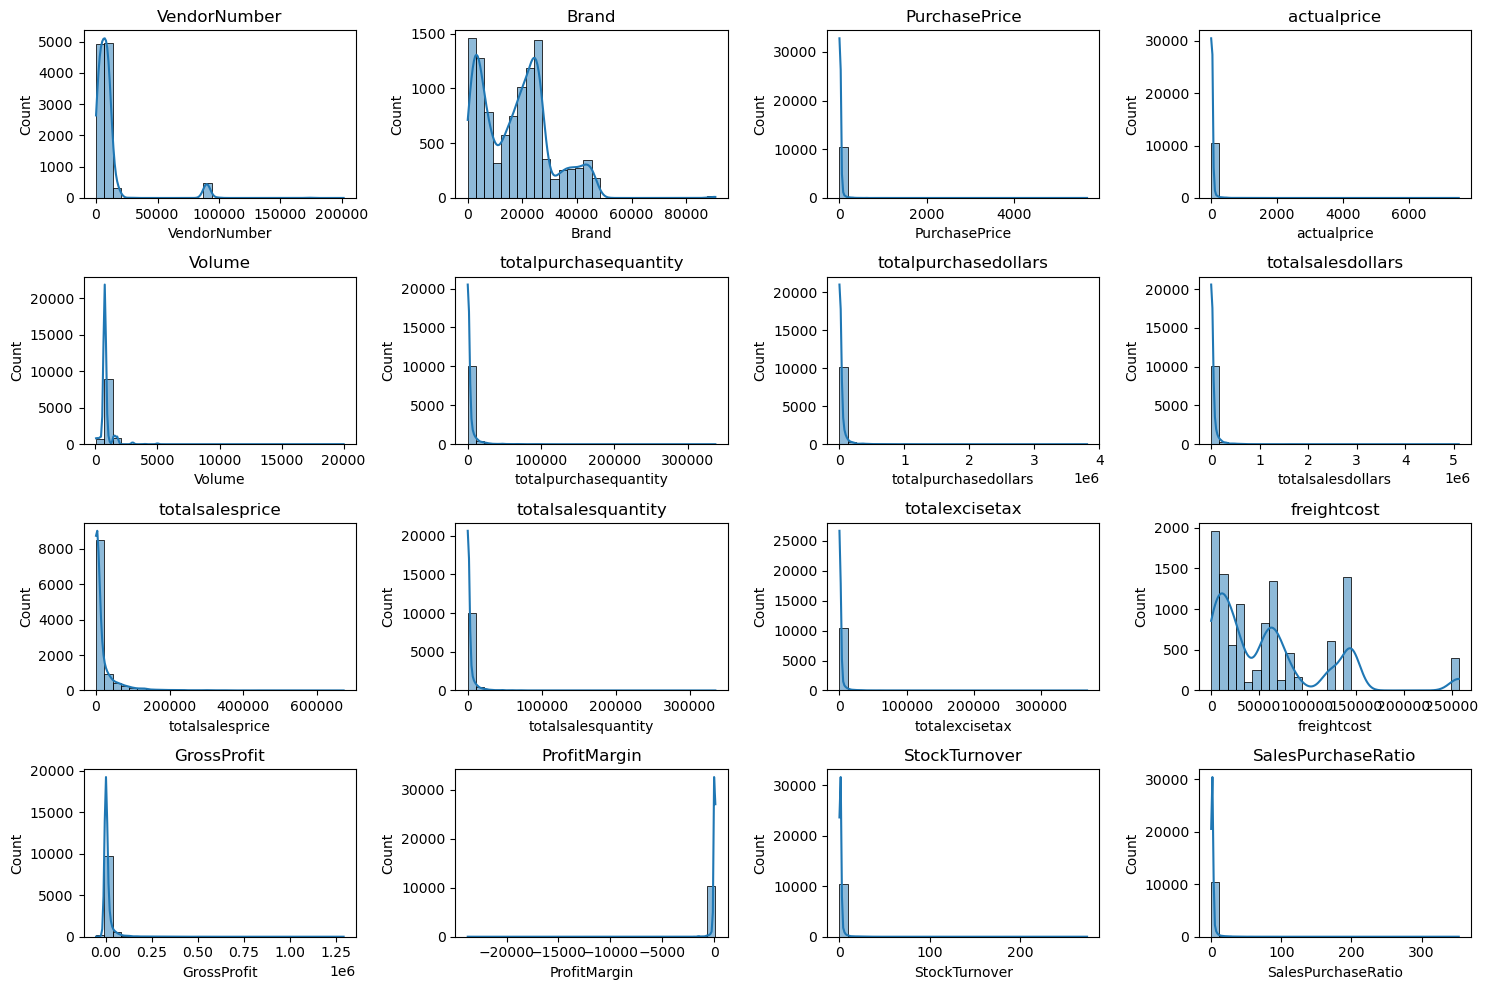

In [6]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

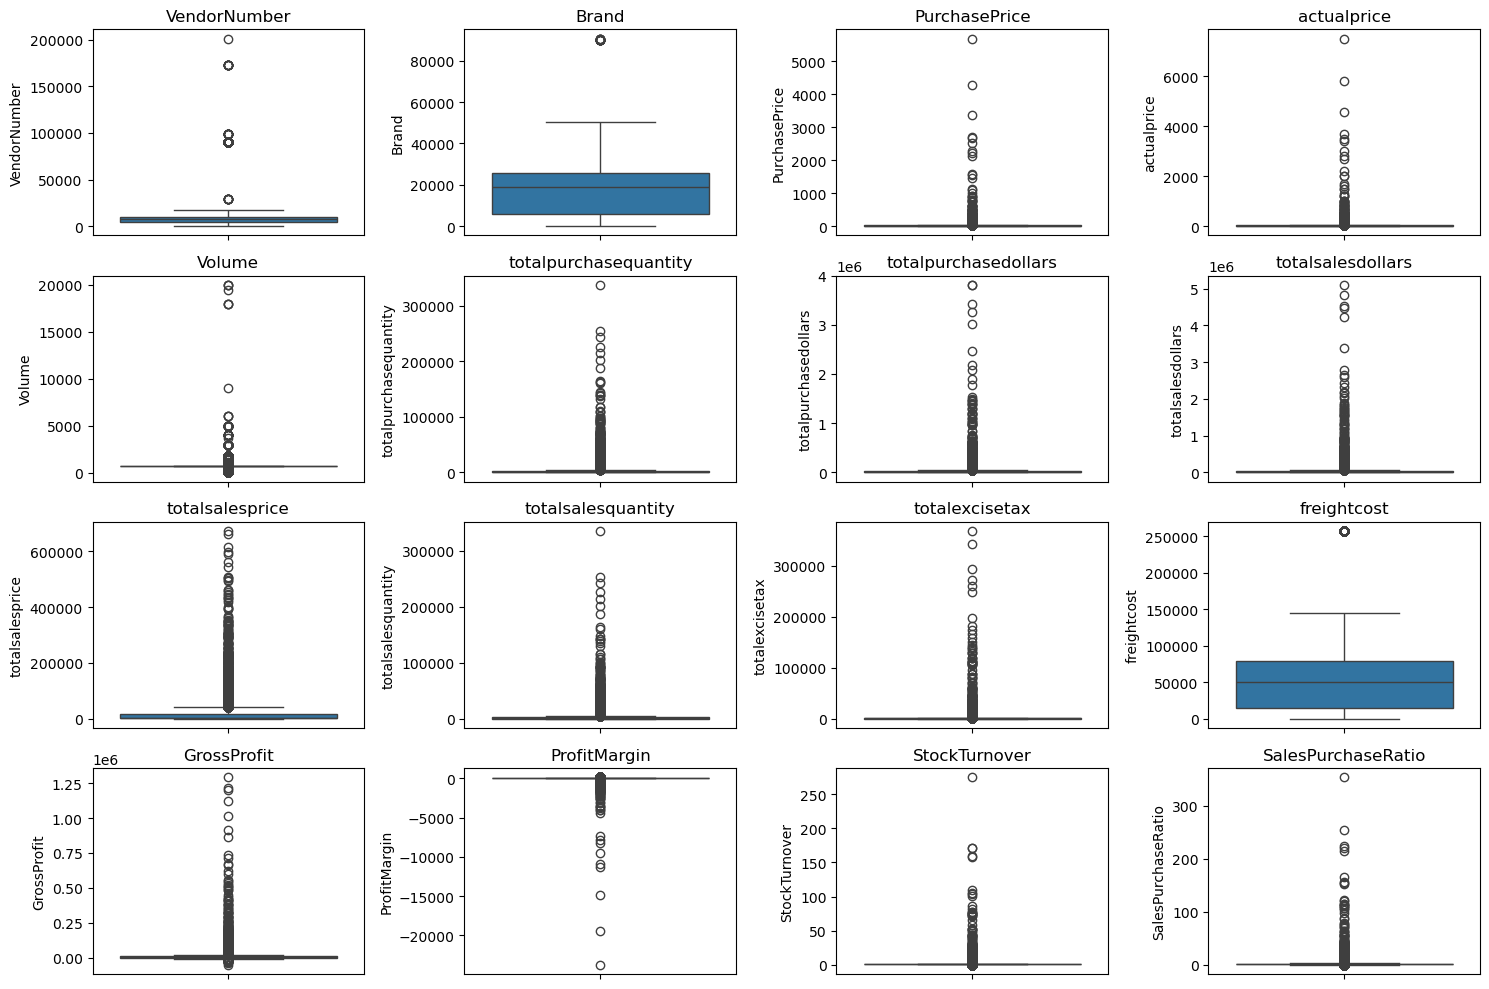

In [7]:
# outlier detection with box plot 
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics Insights
### Negative & Zero Values:
* Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

### Outliers Indicated by High Standard Deviations:

* Purchase & Actual Prices: The max values (5,683.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.


In [8]:
# lets filter the data by removing inconsistencies

df = pd.read_sql_query(""" SELECT * 
                       FROM vendor_sales_summary
                       WHERE "GrossProfit" > 0 AND "ProfitMargin" > 0 
                       AND TotalSalesQuantity > 0 """,conn  )

In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualprice,Volume,totalpurchasequantity,totalpurchasedollars,totalsalesdollars,totalsalesprice,totalsalesquantity,totalexcisetax,freightcost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,15.95,10.96,5.0,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6.0,2.34,65.66,1.47,134.0,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2.0,1.48,1.98,0.99,2.0,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1.0,1.47,143.28,77.61,72.0,15.12,257032.07,141.81,98.974037,72.000000,97.469388


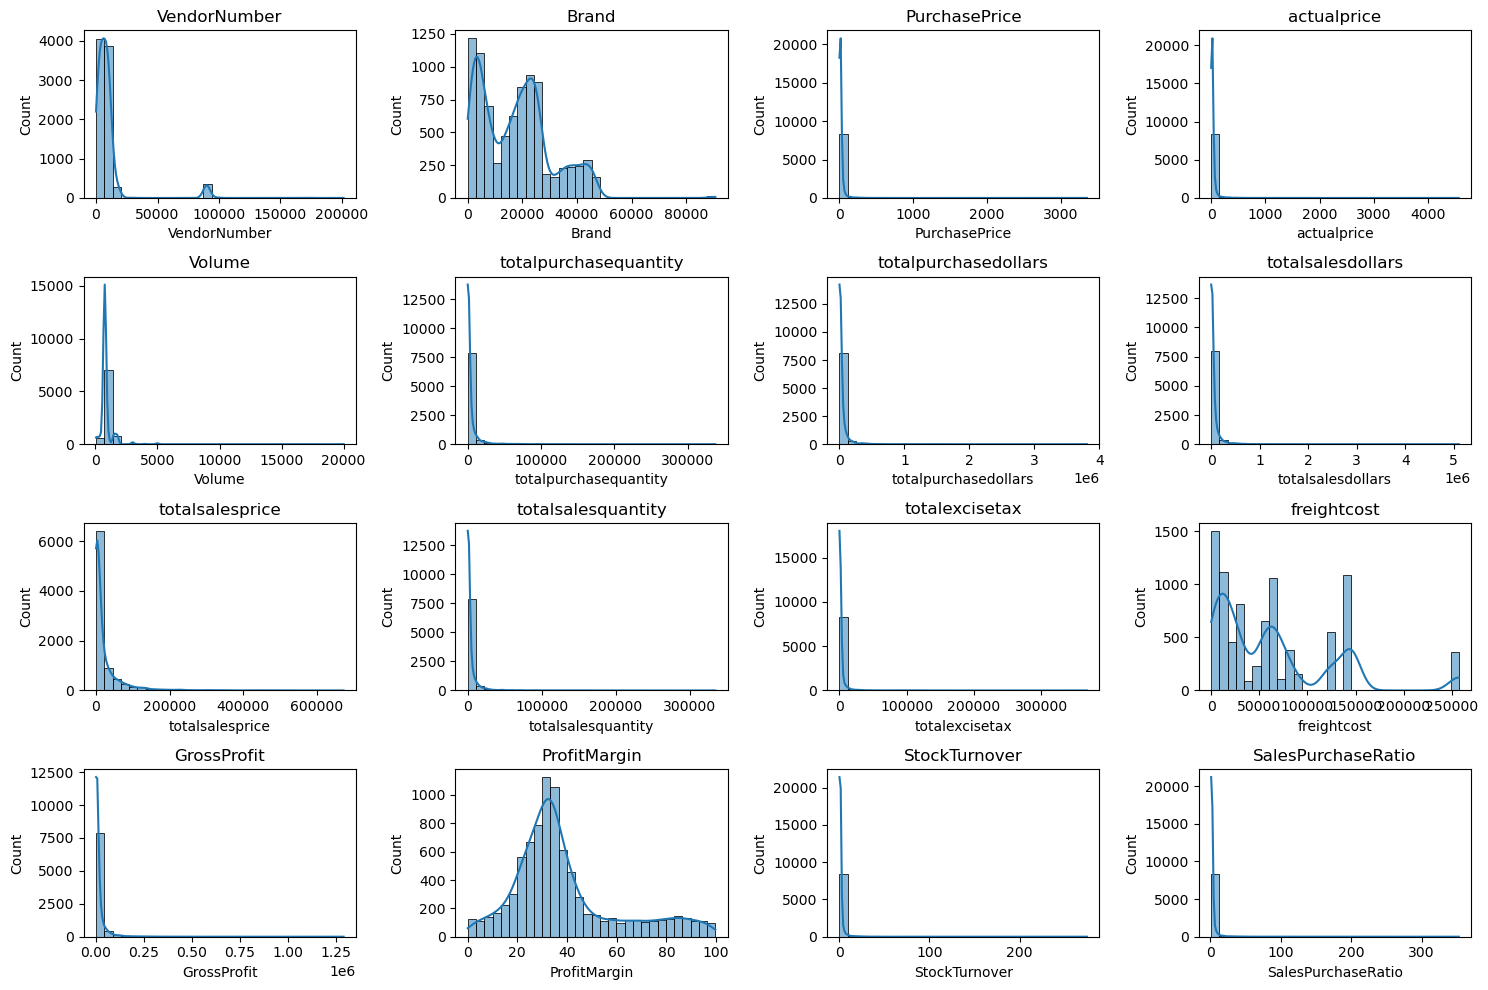

In [10]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

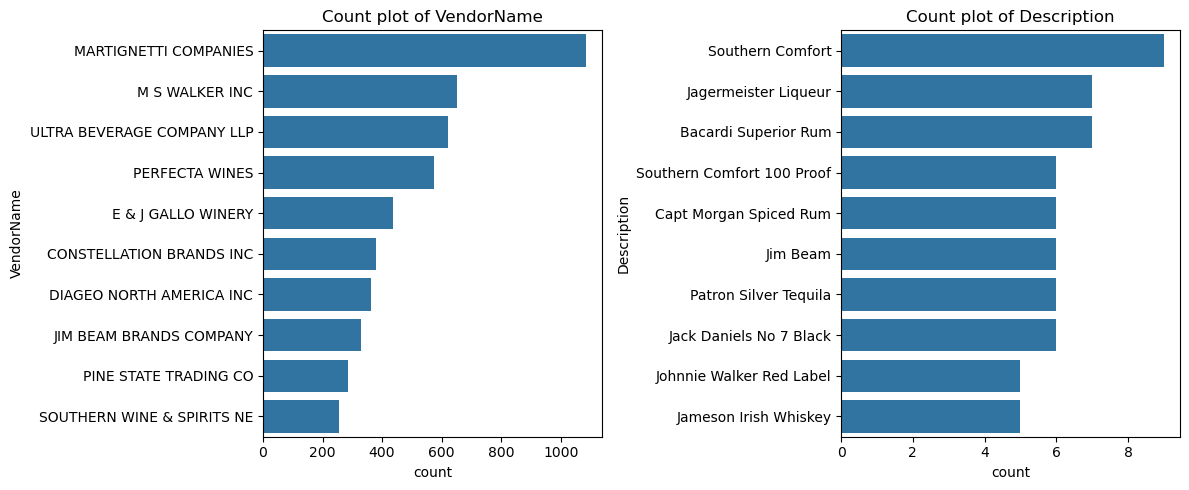

In [11]:
# count plots for categorical columns
categorical_cols = ["VendorName","Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1) # Adjust grid layout as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # top 10 categories
    plt.title(f'Count plot of {col}')
plt.tight_layout()
plt.show()

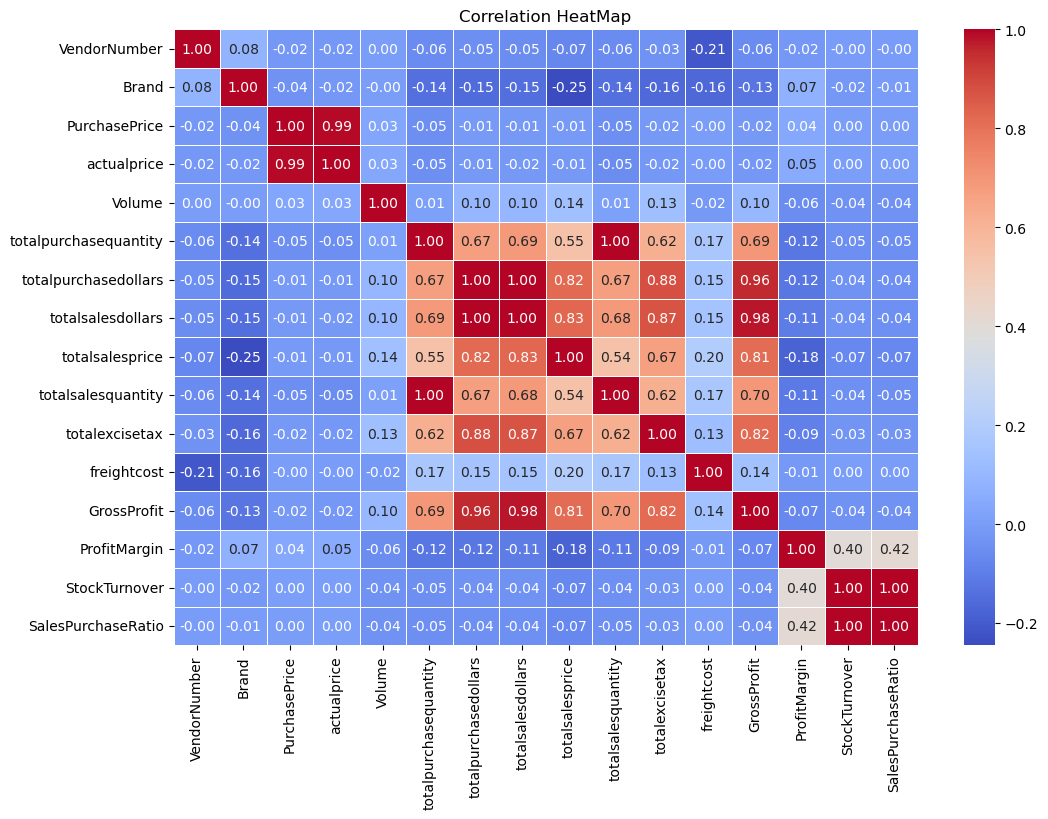

In [13]:
# Correlation heatMap

plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidth=0.5)
plt.title('Correlation HeatMap')
plt.show()

## Correlation Insights

* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
* Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
* StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.


## Data Analysis

#### Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margin 

In [14]:
brand_performance = df.groupby('Description').agg({
    'totalsalesdollars' : 'sum' ,
    'ProfitMargin' : 'mean'
}).sort_values(by='totalsalesdollars', ascending=False)
brand_performance

,totalsalesdollars,ProfitMargin
Description,,
Jack Daniels No 7 Black,7964746.76,26.525491
Tito's Handmade Vodka,7399657.58,28.953634
Grey Goose Vodka,7209608.06,25.413817
Capt Morgan Spiced Rum,6356320.62,27.261764
Absolut 80 Proof,6244752.03,27.051973
...,...,...
Allen's Blue Curacao Liqueur,5.99,20.033389
Smirnoff Light Strawberry,5.94,50.168350
Albero Sparkling Wh Organic,5.79,28.497409


In [ ]:
low_sales_threshold = brand_performance['totalsalesdollars'].quantile(0.15) # 15% of brands have sales below this value
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85) # top 15% highest profit margin brands

In [16]:
low_sales_threshold

np.float64(560.299)

In [17]:
high_margin_threshold

np.float64(64.97017552750113)

In [18]:
target_brands = brand_performance[(brand_performance['totalsalesdollars'] <= low_sales_threshold) &
                                  (brand_performance['ProfitMargin'] >= high_margin_threshold)]

print('Brands with Low sales but high profit margins:')
display(target_brands.sort_values('totalsalesdollars'))

Brands with Low sales but high profit margins:


,totalsalesdollars,ProfitMargin
Description,,
Santa Rita Organic Svgn Bl,9.99,66.466466
Debauchery Pnt Nr,11.58,65.975820
Concannon Glen Ellen Wh Zin,15.95,83.448276
Crown Royal Apple,27.86,89.806174
Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...
Nanbu Bijin Southern Beauty,535.68,76.747312
Dad's Hat Rye Whiskey,538.89,81.851584
A Bichot Clos Marechaudes,539.94,67.740860


In [19]:
brand_performance = brand_performance[brand_performance['totalsalesdollars']<10000] # for better visualization

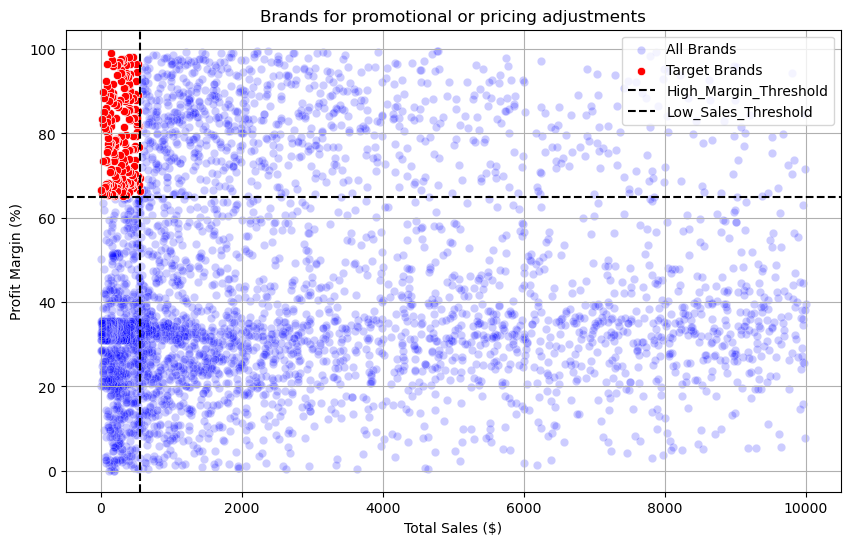

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='totalsalesdollars', y='ProfitMargin', color='blue', label='All Brands', alpha = 0.2)
sns.scatterplot(data=target_brands, x='totalsalesdollars', y='ProfitMargin', color='red', label='Target Brands')

plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High_Margin_Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low_Sales_Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for promotional or pricing adjustments')
plt.legend()
plt.grid(True)
plt.show()

##### Which vendors and brands demonstrate the highest sales performance?

In [21]:
# for formatting values
def format_dollars(value):
    if value >= 1_000_000:
        return f'{value/1_000_000:.2f}M'
    elif value >= 1_000:
        return f'{value/1_000:.2f}K'
    else:
        return str(value)

In [22]:
# top vendors and brands by sales performance
top_vendors = df.groupby('VendorName')['totalsalesdollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['totalsalesdollars'].sum().nlargest(10)

In [23]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: totalsalesdollars, dtype: float64

In [24]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: totalsalesdollars, dtype: float64

| Term  | Meaning                     |
| ----- | --------------------------- |
| `fig` | whole figure/window         |
| `ax`  | one graph inside the figure |


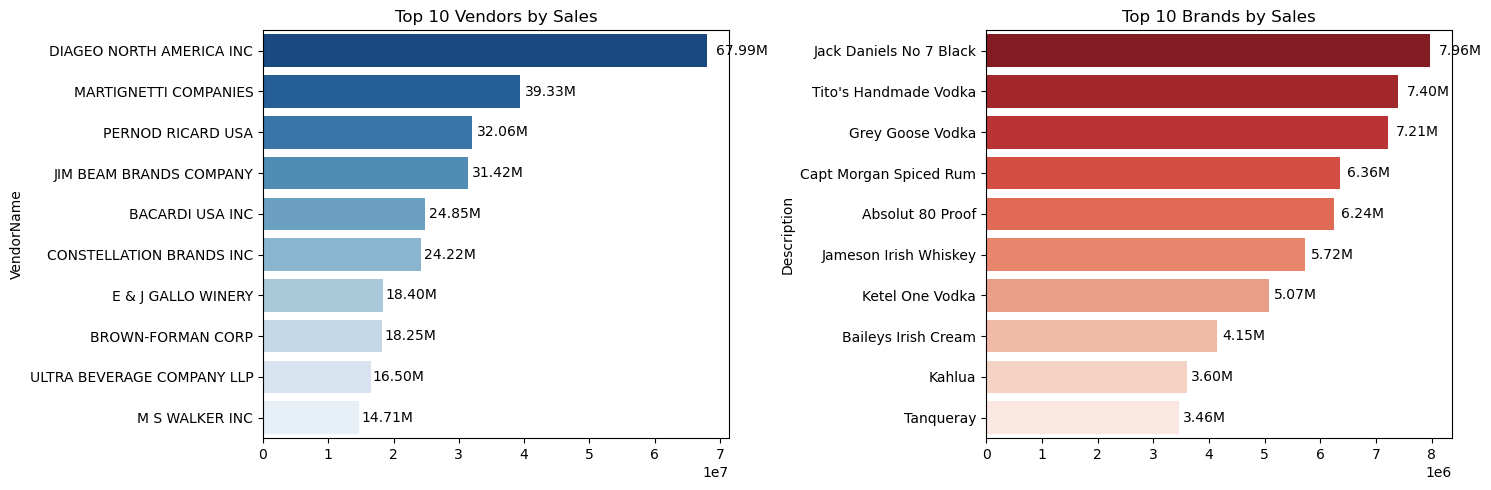

In [25]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches: # All the bar objects (rectangles/shapes) drawn in the plot. In a barplot, every bar is a “patch”
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

#### Which vendor contributes most to total purchase dollars?

In [26]:
vendor_performance = df.groupby('VendorName').agg({
    'totalpurchasedollars':'sum',
    'GrossProfit':'sum',
    'totalsalesdollars':'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [27]:
vendor_performance

,VendorName,totalpurchasedollars,GrossProfit,totalsalesdollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [28]:
vendor_performance['PurchaseContribution%'] = (vendor_performance['totalpurchasedollars'] / vendor_performance['totalpurchasedollars'].sum())*100

In [29]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [30]:
# Display top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors['totalsalesdollars'] = top_vendors['totalsalesdollars'].apply(format_dollars)
top_vendors['totalpurchasedollars'] = top_vendors['totalpurchasedollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors

,VendorName,totalpurchasedollars,GrossProfit,totalsalesdollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [31]:
top_vendors['PurchaseContribution%'].sum()

np.float64(65.69000000000001)

In [32]:
top_vendors['CumulativeContribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,totalpurchasedollars,GrossProfit,totalsalesdollars,PurchaseContribution%,CumulativeContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


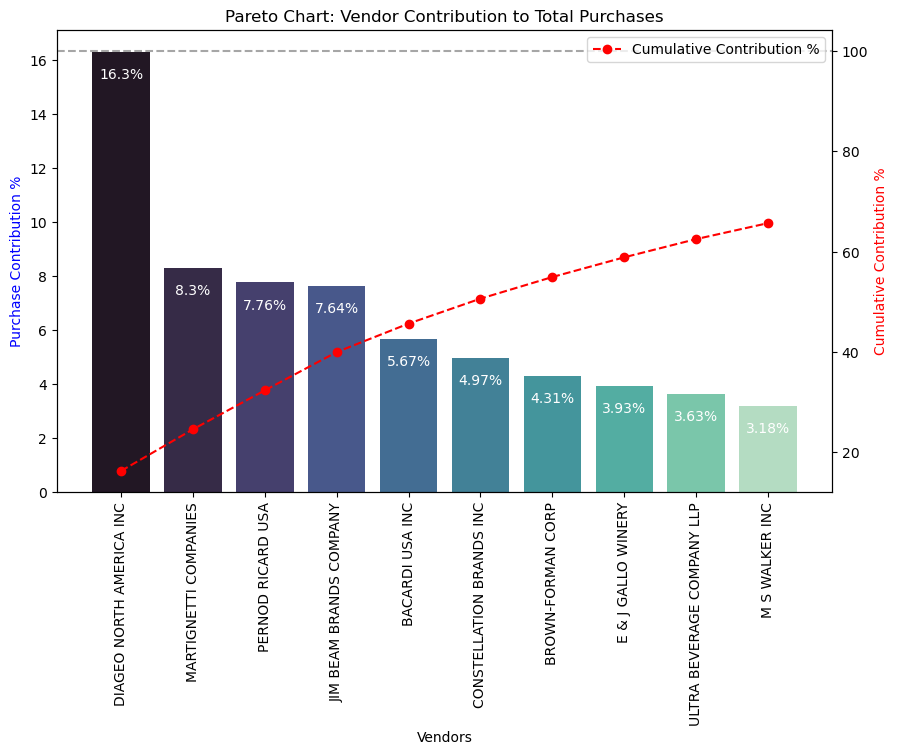

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx() #This creates a second Y-axis sharing the same X-axis in Matplotlib.
ax2.plot(top_vendors['VendorName'], top_vendors['CumulativeContribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative Contribution %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')

plt.show()

#### How much of total procurement is dependent on the top vendors?

In [34]:
print(f'Total Purchase contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %')

Total Purchase contribution of top 10 vendors is 65.69 %


Text(0.5, 1.0, "Top 10 Vendor's Purchase Contribution (%)")

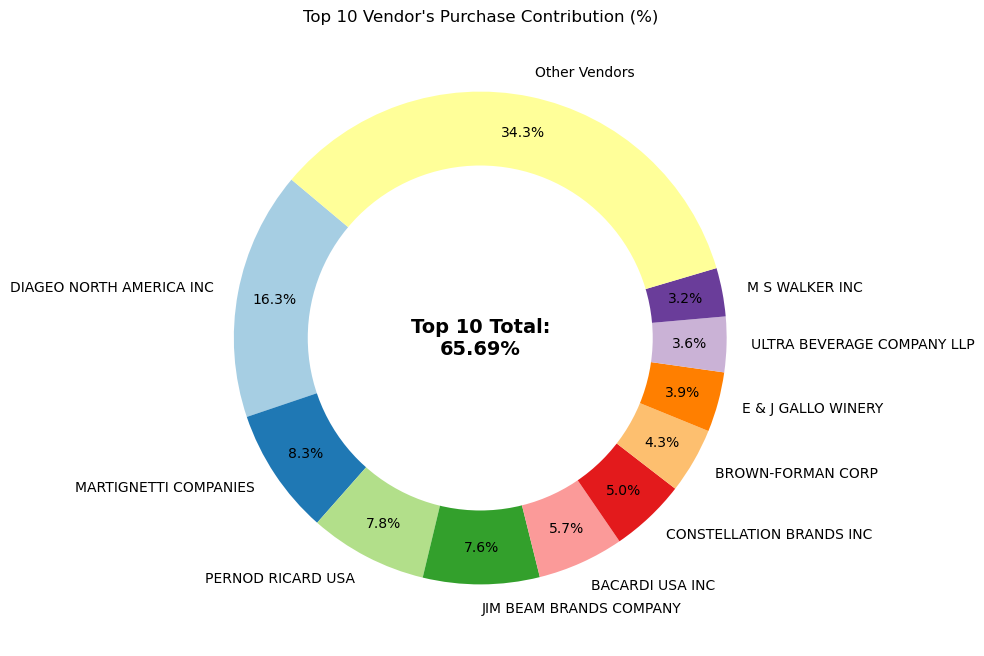

In [35]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")

#### Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for the cost savings?

In [36]:
df['UnitPurchasePrice'] = df['totalpurchasedollars'] / df['totalpurchasequantity']

In [37]:
df['OrderSize'] = pd.qcut(df['totalpurchasequantity'], q=3, labels=['Small', 'Medium','Large'])

In [38]:
df[['OrderSize','totalpurchasequantity']]

,OrderSize,totalpurchasequantity
0,Large,145080.0
1,Large,164038.0
2,Large,187407.0
3,Large,201682.0
4,Large,138109.0
...,...,...
8559,Small,2.0
8560,Small,6.0
8561,Small,2.0
8562,Small,1.0


In [39]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


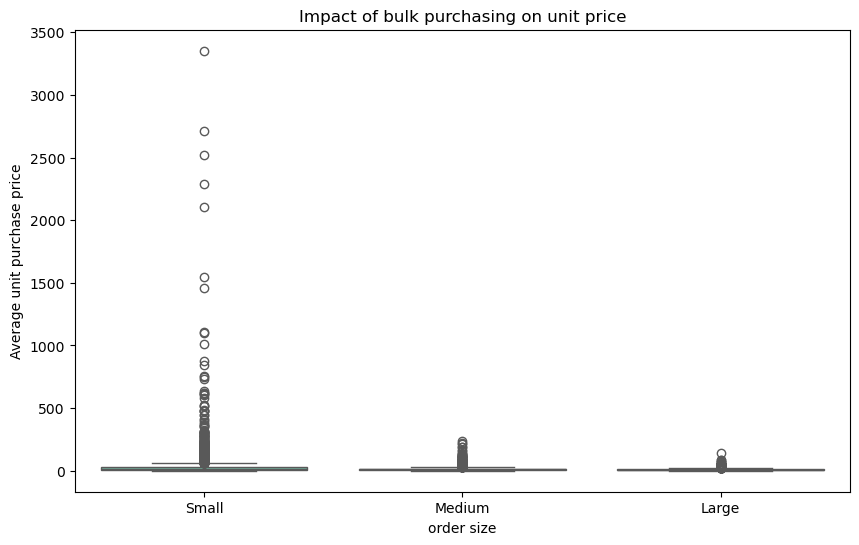

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice', palette='Set2')
plt.title('Impact of bulk purchasing on unit price')
plt.xlabel('order size')
plt.ylabel('Average unit purchase price')
plt.show()

* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
* The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

#### Which vendors have low inventory turnover, indicating excess stock and slow moving products

In [41]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


#### How much capital is locked in unsold inventory per vendor and which vendors contribute the most to it?

In [42]:
df['UnsoldInventoryValue'] = (df['totalpurchasequantity'] - df['totalsalesquantity']) * df['PurchasePrice']
print('Total Unsold capital:', format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold capital: 2.71M


In [43]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


#### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [44]:
top_threshold = df["totalsalesdollars"].quantile(0.75)
low_threshold = df["totalsalesdollars"].quantile(0.25)

In [45]:
top_vendors = df[df["totalsalesdollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["totalsalesdollars"] <= low_threshold]["ProfitMargin"].dropna()

top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3682    85.782102
4751    93.085860
4921    95.012530
5051    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [46]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

A confidence interval is simply:

a “safe range” where the real answer is likely to be.

Because real-world data is never perfectly exact.

Confidence intervals help show:

- uncertainty
- reliability
- how trustworthy the estimate is

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


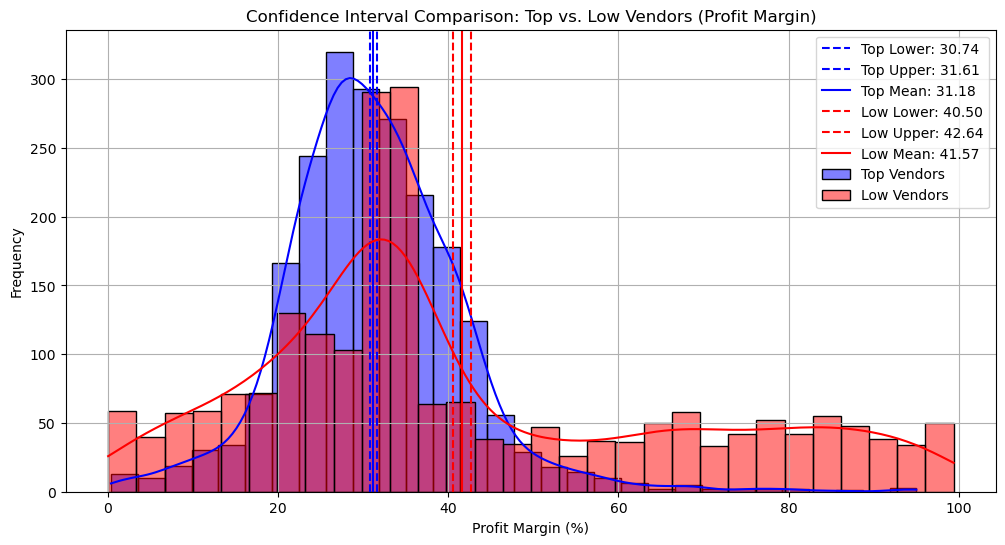

In [47]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

* The confidence interval for low-performing vendors (**40.48% to 42.62%**) is significantly higher than that of top-performing vendors (**30.74% to 31.61%**).
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

### Is there a significant difference in profit margins between top-performing and low-performing vendors?Hypothesis:
- $H_0$ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
- $H_1$ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [48]:
top_threshold = df["totalsalesdollars"].quantile(0.75)
low_threshold = df["totalsalesdollars"].quantile(0.25)

top_vendors = df[df["totalsalesdollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["totalsalesdollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject H0: There is a significant difference in profit margins between top and low-performing vendors.
